# 04 · Removing the tide — harmonic analysis

This is the payoff notebook. The tide is usually the *biggest* signal in the
pressure record, but often it's the part we want to **get rid of** — to see what
the ocean is doing underneath it (storms, currents, sea-level change). The
classic tool is **harmonic analysis**, exactly as described in the standard
textbook *Data Analysis Methods in Physical Oceanography* by **Richard E.
Thomson & William J. Emery** (Chapter 5).

We'll build it from scratch in NumPy so nothing is a black box, then optionally
cross-check against the `utide` package.

> 🎯 **What you'll learn in this notebook**
>
> - Understand *why* the tide is a sum of fixed-frequency 'constituents'
> - Fit those constituents to data by least squares (the T&E method)
> - Use the fit to PREDICT the tide and SUBTRACT it
> - Read constituent amplitudes and the tidal 'form factor'
> - Confirm with a spectrum that the tidal peaks are gone

## The big idea (no equations yet)

The tide is driven by the **gravity of the Moon and Sun** as the Earth rotates.
Because the orbits are clockwork-regular, the tide is the sum of a *fixed* set of
pure waves, each at a precisely known frequency. These are called **tidal
constituents**, each with a two-letter+number name:

| name | period | driven by |
|------|--------|-----------|
| **M2** | 12.42 h | Moon, twice daily (the big one) |
| **S2** | 12.00 h | Sun, twice daily |
| **N2** | 12.66 h | Moon's elliptical orbit |
| **K1** | 23.93 h | Moon+Sun, once daily |
| **O1** | 25.82 h | Moon, once daily |

The **size** (amplitude) and **timing** (phase) of each constituent depends on
your location — the shape of the coastline and seafloor. **Harmonic analysis**
is the procedure that *measures* those amplitudes and phases from your data.
Once you have them, you can compute the tide at *any* time — past or future.
That's literally how tide tables are made.

> 📖 **Constituent** — one pure cosine wave at a fixed astronomical frequency (e.g. M2 = 12.42 h). The tide is their sum.

> 📖 **Amplitude & phase** — amplitude = how tall a constituent's wave is; phase = where in its cycle it is at a reference time. Harmonic analysis solves for both.

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


## Step 1 · Load a clean ~60-day hourly pressure series

Harmonic analysis needs a continuous, evenly-spaced series. Hourly is plenty for
the tide (its fastest wiggle is ~12 h). We take 60 gap-free days, interpolate any
tiny holes, and use pressure as our sea-level stand-in.

AXBA1: 1453 hourly samples  2015-03-19 00:00:00 → 2015-05-18 23:00:00


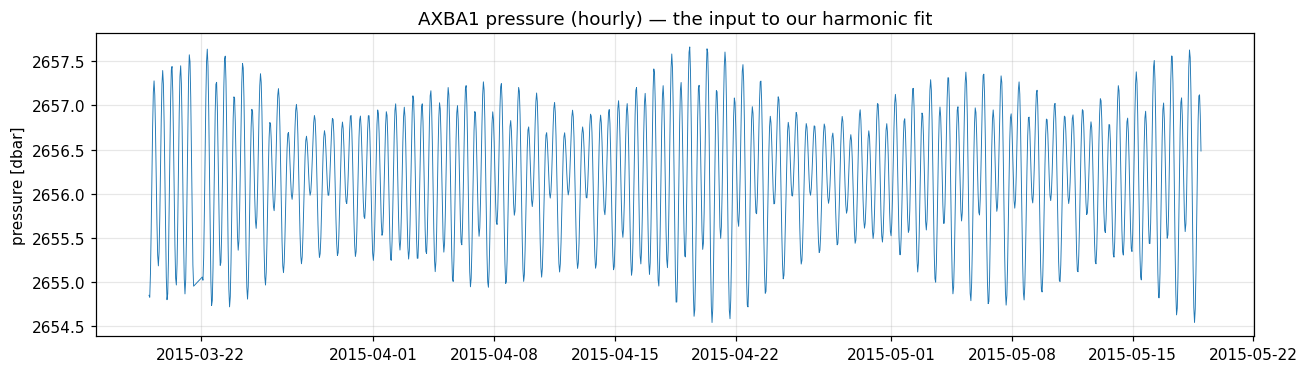

In [2]:
STATION = "AXBA1"
win = ol.DEMO[STATION]
t0 = pd.Timestamp(win["start"]) + pd.Timedelta(days=10)
t1 = t0 + pd.Timedelta(days=60)

s = ol.load_decimated(STATION, "pressure", t0, t1, rule="1h").interpolate(limit=3)
s = s.dropna()
print(f"{STATION}: {len(s)} hourly samples  {s.index[0]} → {s.index[-1]}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(s.index, s.values, lw=0.6)
ax.set_title(f"{STATION} pressure (hourly) — the input to our harmonic fit")
ax.set_ylabel("pressure [dbar]"); plt.tight_layout(); plt.show()

> 👀 **What you're seeing**
>
> 60 days of tide. The obvious ~2-week swelling and shrinking of the envelope is the spring–neap cycle (which is really M2 and S2 beating against each other). Our job: find the constituents that add up to this curve.

## Step 2 · List the constituents and their frequencies

Each constituent has an astronomically-fixed **speed** in *degrees per hour*
(how fast its phase advances). Frequency in cycles/hour = speed / 360. These
numbers are universal constants — the same everywhere on Earth.

In [3]:
# name : degrees per (solar) hour  — standard tidal speeds
CONSTITUENTS = {
    "Mm":  0.5443747,   # monthly   (Moon's orbit)
    "Mf":  1.0980331,   # fortnightly
    "Q1": 13.3986609, "O1": 13.9430356, "P1": 14.9589314, "K1": 15.0410686,   # diurnal (~daily)
    "N2": 28.4397295, "M2": 28.9841042, "S2": 30.0000000, "K2": 30.0821373,   # semidiurnal (~twice daily)
    "M4": 57.9682084, "MS4": 58.9841042,                                       # shallow-water 'overtides'
}
freqs = {k: v / 360.0 for k, v in CONSTITUENTS.items()}    # cycles per hour
pd.Series(CONSTITUENTS, name="deg/hr").to_frame().assign(
    period_h=lambda d: 360.0 / d["deg/hr"])                 # period = 360 / speed

,deg/hr,period_h
Mm,0.544375,661.309205
Mf,1.098033,327.858969
Q1,13.398661,26.868357
O1,13.943036,25.819342
P1,14.958931,24.065890
K1,15.041069,23.934470
N2,28.439729,12.658348
M2,28.984104,12.420601
S2,30.000000,12.000000
K2,30.082137,11.967235


> 👀 **What you're seeing**
>
> The 'period_h' column is each wave's repeat time in hours. Note the families: ~12 h (semidiurnal), ~24 h (diurnal), and the slow fortnightly/monthly ones. M4/MS4 are 'overtides' created when the tide is distorted in shallow water.

## Step 3 · The least-squares fit (the heart of the method)

We claim the data $y(t)$ is approximately

$$y(t) \approx \underbrace{Z_0}_{\text{mean}} + \underbrace{c\,t}_{\text{slow drift}}
   + \sum_k \big[a_k\cos(2\pi f_k t) + b_k\sin(2\pi f_k t)\big].$$

Why cos **and** sin for each constituent? Because together they can make a wave
of *any* amplitude **and** any phase — and crucially the unknowns
$a_k, b_k$ enter **linearly**, so we can solve for them with ordinary
**least squares** (find the numbers that minimise the squared misfit). We add a
constant ($Z_0$) and a straight-line trend ($c\,t$) to soak up the mean level and
slow instrument drift.

In code: build a matrix `X` whose columns are `[1, t, cos(2πf₁t), sin(2πf₁t),
cos(2πf₂t), …]`, then `np.linalg.lstsq` finds the best coefficients. From each
cos/sin pair we recover amplitude $A_k=\sqrt{a_k^2+b_k^2}$ and phase
$\phi_k=\operatorname{atan2}(b_k,a_k)$.

> 📖 **Least squares** — the workhorse fitting method: pick the coefficients that make the total squared difference between the model and the data as small as possible. One line: `np.linalg.lstsq`.

In [4]:
# x-axis for the fit = hours since the first sample (a plain number, not a date)
t_hours = ((s.index - s.index[0]) / pd.Timedelta(hours=1)).values.astype(float)
y = s.values.astype(float)

# Build the design matrix X, one column at a time.
cols  = [np.ones_like(t_hours), t_hours]        # column 0 = mean (Z0), column 1 = linear trend
names = ["mean", "trend"]
for name, f in freqs.items():
    w = 2 * np.pi * f                            # angular frequency
    cols  += [np.cos(w * t_hours), np.sin(w * t_hours)]
    names += [f"{name}_cos", f"{name}_sin"]
X = np.column_stack(cols)

# Solve  X @ beta ≈ y  in the least-squares sense.
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
coef = dict(zip(names, beta))

# Convert each cos/sin pair into amplitude & phase.
rows = []
for name, f in freqs.items():
    a, b = coef[f"{name}_cos"], coef[f"{name}_sin"]
    rows.append({"constituent": name, "period_h": 1 / f,
                 "amplitude": np.hypot(a, b),                     # sqrt(a^2 + b^2)
                 "phase_deg": np.degrees(np.arctan2(b, a)) % 360})
amps = pd.DataFrame(rows).set_index("constituent").sort_values("amplitude", ascending=False)
amps.round(2)

,period_h,amplitude,phase_deg
constituent,,,
M2,12.42,0.83,190.16
K1,23.93,0.37,145.19
S2,12.00,0.23,257.17
O1,25.82,0.20,274.98
N2,12.66,0.18,152.52
P1,24.07,0.12,315.84
K2,11.97,0.05,237.68
Q1,26.87,0.04,256.42
Mf,327.86,0.01,183.84


> 👀 **What you're seeing**
>
> The table is your tidal fingerprint for this site, sorted biggest first. For the US Pacific NW you should see **M2** on top, with **K1, S2, O1, N2** following — the classic ranking for this coast.

### Visualise the constituent amplitudes

saved /Users/quakehunter/Documents/data_exploration/figures/04_AXBA1_constituents.png


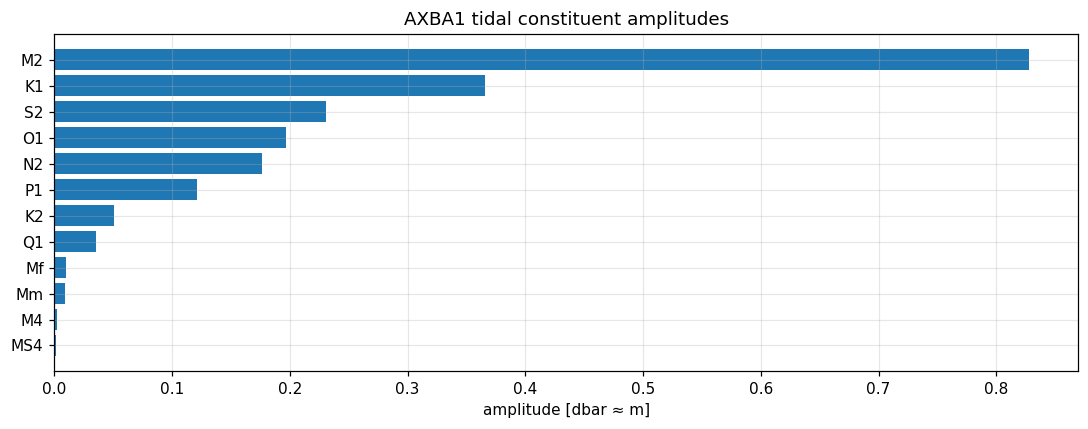

Form factor F = (K1+O1)/(M2+S2) = 0.53  ->  mixed, mainly semidiurnal tide


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
amps_sorted = amps.sort_values("amplitude")
ax.barh(amps_sorted.index, amps_sorted["amplitude"], color="C0")
ax.set_xlabel("amplitude [dbar ≈ m]"); ax.set_title(f"{STATION} tidal constituent amplitudes")
plt.tight_layout(); ol.savefig(fig, f"04_{STATION}_constituents.png"); plt.show()

# The 'form factor' classifies the tide's character in one number.
F = ((amps.loc['K1','amplitude'] + amps.loc['O1','amplitude']) /
     (amps.loc['M2','amplitude'] + amps.loc['S2','amplitude']))
kind = ("semidiurnal" if F < 0.25 else "mixed, mainly semidiurnal" if F < 1.5
        else "mixed, mainly diurnal" if F < 3 else "diurnal")
print(f"Form factor F = (K1+O1)/(M2+S2) = {F:.2f}  ->  {kind} tide")

> 📖 **Form factor F** — (K1+O1)/(M2+S2). A single number describing tide type: <0.25 semidiurnal (two equal tides/day), 0.25–1.5 mixed mainly semidiurnal, 1.5–3 mixed mainly diurnal, >3 diurnal (one tide/day).

## Step 4 · Predict the tide, then subtract it

Now we *rebuild* the tide using only the constituent terms (keep the mean so the
curve sits at the right level, but **drop the linear-trend term** so the leftover
residual still contains the real slow sea-level changes we want to study).

**Residual = observed − predicted tide.** This is the de-tided signal — the
ocean's "weather".

Variance explained by the tidal fit: 99.7%


saved /Users/quakehunter/Documents/data_exploration/figures/04_AXBA1_detide.png


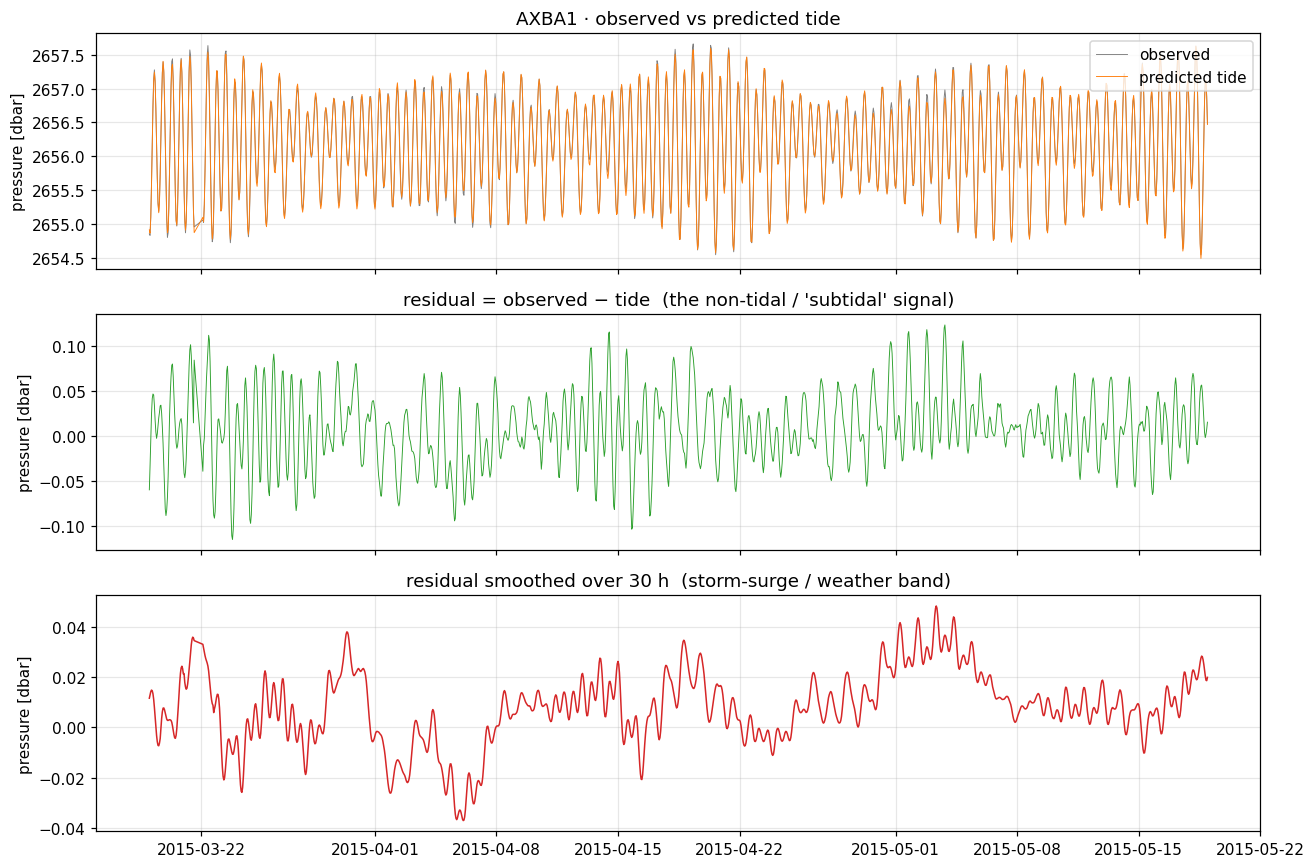

In [6]:
# Reconstruct the tide from the fitted coefficients.
tide_only = np.full_like(y, coef["mean"])                 # start at the mean level
for name, f in freqs.items():
    w = 2 * np.pi * f
    tide_only += coef[f"{name}_cos"]*np.cos(w*t_hours) + coef[f"{name}_sin"]*np.sin(w*t_hours)

tide  = pd.Series(tide_only, index=s.index)
resid = s - tide                                          # <-- the de-tided signal
var_explained = 1 - resid.var() / s.var()
print(f"Variance explained by the tidal fit: {100*var_explained:.1f}%")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(s.index, s.values, "C7", lw=0.6, label="observed")
axes[0].plot(tide.index, tide.values, "C1", lw=0.6, label="predicted tide")
axes[0].legend(loc="upper right"); axes[0].set_title(f"{STATION} · observed vs predicted tide")
axes[1].plot(resid.index, resid.values, "C2", lw=0.6)
axes[1].set_title("residual = observed − tide  (the non-tidal / 'subtidal' signal)")
axes[2].plot(resid.index, resid.rolling(30, center=True, min_periods=1).mean().values, "C3", lw=1.0)
axes[2].set_title("residual smoothed over 30 h  (storm-surge / weather band)")
for a in axes: a.set_ylabel("pressure [dbar]")
plt.tight_layout(); ol.savefig(fig, f"04_{STATION}_detide.png"); plt.show()

> 👀 **What you're seeing**
>
> **Top:** the orange predicted tide should sit almost exactly on the grey data — that's the 'variance explained' number (typically >99% for pressure here). **Middle:** the residual is tiny by comparison and looks irregular — that's the point, the clockwork tide is gone. **Bottom:** smoothing the residual reveals slow bumps that are real ocean/weather events, not tides.

### Zoom in on the first week to check the fit by eye

saved /Users/quakehunter/Documents/data_exploration/figures/04_AXBA1_detide_zoom.png


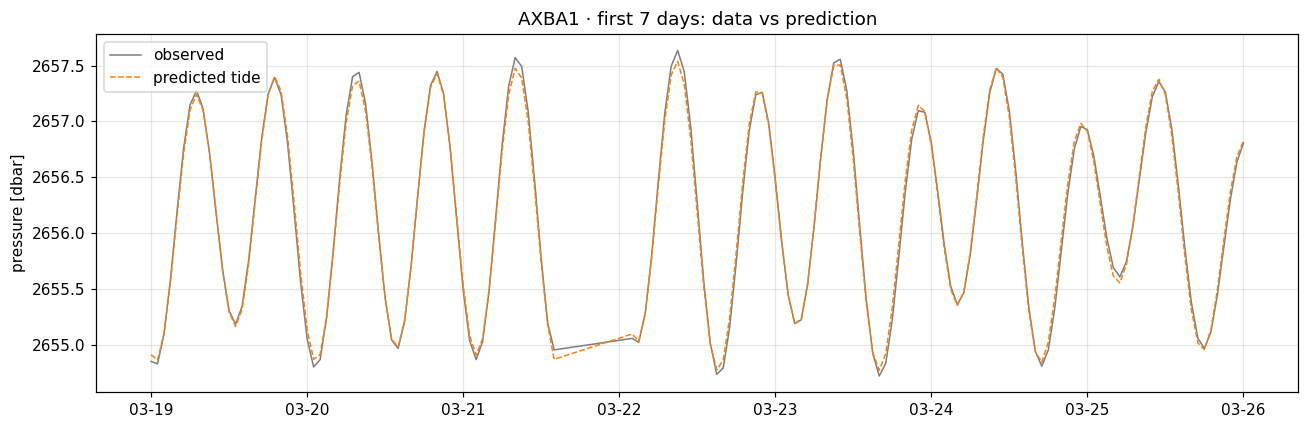

In [7]:
sl = slice(s.index[0], s.index[0] + pd.Timedelta(days=7))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(s.loc[sl].index, s.loc[sl].values, "C7", lw=1, label="observed")
ax.plot(tide.loc[sl].index, tide.loc[sl].values, "C1--", lw=1, label="predicted tide")
ax.legend(); ax.set_title(f"{STATION} · first 7 days: data vs prediction"); ax.set_ylabel("pressure [dbar]")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout(); ol.savefig(fig, f"04_{STATION}_detide_zoom.png"); plt.show()

> 👀 **What you're seeing**
>
> The dashed prediction should trace the data almost perfectly, capturing both the twice-daily humps and the unequal heights of successive highs (the 'mixed' character F told us about).

## Step 4b · Is it overfitting? An out-of-sample check

A 99%+ "variance explained" can be a lie if we just fit noise. The honest test
of any predictive model is **out-of-sample skill**: fit on data it *hasn't* seen,
then predict. Here we fit the constituents on the **first half** of the record
and use them to predict the **second half**. If the tide is real (it is), the
two scores should be almost equal. A big drop would mean overfitting.

In [8]:
n = len(s); half = n // 2
Xh = X[:half]                                   # design matrix, first half only
beta_half, *_ = np.linalg.lstsq(Xh, y[:half], rcond=None)

def predict_tide(beta_vec):
    out = np.full_like(t_hours, beta_vec[0])     # mean, no trend
    for j, f in enumerate(freqs.values()):
        w = 2 * np.pi * f
        out += beta_vec[2 + 2*j] * np.cos(w * t_hours) + beta_vec[3 + 2*j] * np.sin(w * t_hours)
    return out

pred = predict_tide(beta_half)
ve_in  = 1 - np.var(y[:half] - pred[:half]) / np.var(y[:half])
ve_out = 1 - np.var(y[half:] - pred[half:]) / np.var(y[half:])
print(f"Fit on first half, score on each half:")
print(f"   in-sample  (first half) : {100*ve_in:5.2f}%")
print(f"   OUT-OF-SAMPLE (2nd half): {100*ve_out:5.2f}%   <-- the number that matters")
print("Near-equal scores  ->  the tidal fit genuinely predicts unseen data (not overfitting).")

Fit on first half, score on each half:
   in-sample  (first half) : 99.65%
   OUT-OF-SAMPLE (2nd half): 99.43%   <-- the number that matters
Near-equal scores  ->  the tidal fit genuinely predicts unseen data (not overfitting).


> 👀 **What you're seeing**
>
> The two percentages come out within a fraction of a percent of each other (~99.4% vs ~99.7%). That tiny gap is the proof: the constituents we solved for predict data they were never shown, so we're capturing real tidal physics, not fitting noise.

## Step 5 · Prove it with a spectrum

A **spectrum** (periodogram) shows how much of a signal's energy sits at each
frequency — sharp spikes mean strong periodic waves. If de-tiding worked, the
spikes at the **diurnal (~1 cycle/day)** and **semidiurnal (~2 cycles/day)**
bands should collapse in the residual.

> 📖 **Spectrum / periodogram** — a plot of signal energy vs frequency. A pure tide shows tall narrow spikes at its constituent frequencies; random 'weather' is broad and low.

saved /Users/quakehunter/Documents/data_exploration/figures/04_AXBA1_spectra.png


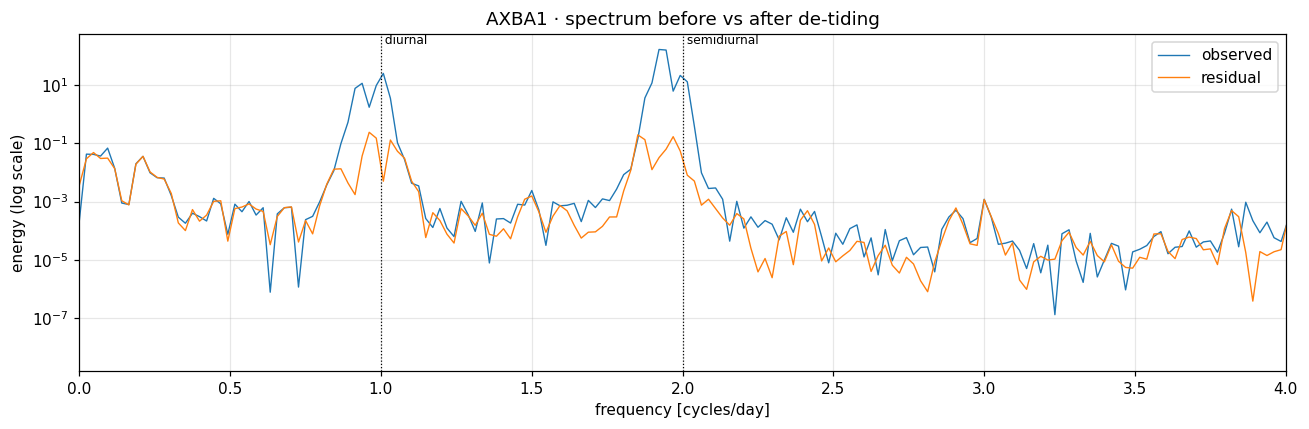

In [9]:
from scipy.signal import welch
fs = 1.0  # sampling frequency in cycles per hour (data is hourly)
for label, ser in [("observed", s), ("residual", resid)]:
    f, P = welch(ser.values - ser.values.mean(), fs=fs, nperseg=min(1024, len(ser)))
    plt.semilogy(f * 24, P, lw=0.9, label=label)        # x converted to cycles/DAY
plt.axvline(1, ls=":", c="k", lw=0.8); plt.axvline(2, ls=":", c="k", lw=0.8)
plt.text(1, plt.ylim()[1], " diurnal", va="top", fontsize=8)
plt.text(2, plt.ylim()[1], " semidiurnal", va="top", fontsize=8)
plt.xlim(0, 4); plt.xlabel("frequency [cycles/day]"); plt.ylabel("energy (log scale)")
plt.title(f"{STATION} · spectrum before vs after de-tiding"); plt.legend()
plt.tight_layout(); ol.savefig(plt.gcf(), f"04_{STATION}_spectra.png"); plt.show()

> 👀 **What you're seeing**
>
> The 'observed' curve has towering spikes at 1 and 2 cycles/day. In the 'residual' curve those spikes drop by orders of magnitude (note the log y-axis) — direct proof the tide was removed and only the broadband non-tidal signal remains.

## Step 6 · (Optional) cross-check with the `utide` package

Everything above is hand-built so you can see the mechanism. In real work people
use **`utide`**, a packaged version of this same least-squares method that also
adds professional touches (18.6-year 'nodal' corrections, confidence intervals).
This cell runs it *if it's installed*; otherwise it tells you how to get it.

In [10]:
try:
    import utide
    coef_u = utide.solve(s.index.to_pydatetime(), s.values,
                         lat=45.8, method="ols", conf_int="MC", verbose=False)
    rec = utide.reconstruct(s.index.to_pydatetime(), coef_u, verbose=False)
    resid_u = s.values - rec.h
    print("utide variance explained: %.1f%%" % (100*(1 - np.var(resid_u)/np.var(s.values))))
    top = pd.DataFrame({"name": coef_u["name"], "A": coef_u["A"]}).set_index("name")
    print(top.sort_values("A", ascending=False).head(8).round(1))
except ImportError:
    print("utide not installed — the NumPy fit above is fully self-contained.")
    print("To enable this cross-check, run:  pip install utide")

utide not installed — the NumPy fit above is fully self-contained.
To enable this cross-check, run:  pip install utide


> ✏️ **Try it yourself**
>
> 1. Re-run the whole notebook with `STATION='HYS14'` or `'HYSB1'`. Do the top constituents change?
> 2. Make `t1 = t0 + pd.Timedelta(days=180)` (6 months). Does the fit improve? (Hint: longer records separate close constituents better.)
> 3. De-tide TEMPERATURE instead of pressure: change 'pressure' to 'temperature' in Step 1. How much variance does the tide explain there?
> 4. Remove M4/MS4 from CONSTITUENTS and re-run. Does variance-explained drop much? (They matter more in shallow water.)

---
## ✅ Recap & important caveats

**You did it:** you measured the tidal constituents at a real seafloor site by
least squares, used them to predict the tide, subtracted it, and proved (via the
spectrum) that the non-tidal residual is what's left. This *is* the Thomson &
Emery harmonic method.

A few honest caveats to remember:

* **Units.** Pressure is reported in **dbar** (oceanlib converts the raw counts
  at 1e-4 dbar/count). Since 1 dbar ≈ 1.02 m of seawater, the constituent
  amplitudes are effectively in **metres of sea level** — note M2 comes out
  ≈0.83 m, the textbook NE-Pacific value, a nice sanity check on the whole chain.
  The conversion factor isn't shipped in the files; it was pinned down from the
  three sites' known depths and that M2 value (see `oceanlib.COUNTS_PER_DBAR`).
* **Record length sets resolution.** To cleanly separate two nearby
  constituents you need a record at least as long as one full "beat" between
  them (the **Rayleigh criterion**): S2 vs K2 needs ~182 days, P1 vs K1 ~183
  days. With 60 days the *big* constituents (M2, K1, S2, O1) are rock-solid —
  they barely move when you refit on 60 vs 480 days — but the small close-pair
  ones (**K2, P1**) wobble ~10%. They're tiny, so this barely affects the
  *removal*; just don't quote their individual amplitudes precisely. Rerun on a
  longer window to sharpen them (AXBA1 has 491 contiguous days).
* **Long-period constituents on short records.** **Mm** has a ~27.6-day period,
  so a 60-day record contains only ~2 cycles of it — its amplitude is poorly
  constrained and it can soak up genuine *non-tidal* low-frequency energy
  (weather, eddies). If your goal is to *study* the subtidal residual, consider
  dropping `Mm` (and even `Mf`) from `CONSTITUENTS`, or use a much longer record.
* **What the phases mean here.** The `phase_deg` we report is measured **relative
  to the first sample of this record**, not the standard astronomical
  (Greenwich) reference used in published harmonic constants. They're correct for
  *predicting/removing* the tide in this series, but **don't compare them to
  tide-table values** — for that you'd need the astronomical argument corrections
  that `utide` applies.
* **Hourly averaging.** We fit hourly means, which gently smooth the fastest
  constituents (M4/MS4, ~6 h) by ~1–2%. Negligible here, and it doubles as
  anti-aliasing. Don't try to fit anything with a period under ~2 hours from
  hourly data (the Nyquist limit).
* **Nodal corrections.** The Moon's orbit slowly wobbles over 18.6 years,
  modulating constituent amplitudes. Our hand fit ignores this; `utide` includes
  it. For records of a year or less the effect is small.

**Where to go next:** apply this to temperature to study internal tides; compare
constituents between the three stations; or feed the residual into storm-surge
or current analysis.